# Эксперименты и графики для одного алгоритма слепой деконволюции

Ноутбук для прогона конкретного алгоритма на тестовых датасетах и построения индивидуальных графиков.

**Инструкция по использованию:**
1. **Ячейка 2 (Настройка)** — задать алгоритм, параметры, пути к папкам
2. **Ячейки 3–4 (Датасет)** — настройка датасета + прогон. Копировать эту пару для каждого нового датасета
3. **Последняя ячейка** — финальная сводка по всем датасетам для данного алгоритма

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 1. Общая настройка ноутбука: алгоритм, пути, параметры
# ══════════════════════════════════════════════════════════════════════════════
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from pathlib import Path
from typing import Optional, Dict, List, Tuple

# ── Автоопределение корня проекта ────────────────────────────────────────────
_nb_dir = Path(os.path.abspath("")).resolve()
PROJECT_ROOT = _nb_dir
for _p in [_nb_dir] + list(_nb_dir.parents):
    if (_p / "pyproject.toml").exists() or (_p / "src").is_dir():
        PROJECT_ROOT = _p
        break

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)

import visualisation as vis  # <-- все графики и TeX-генерация

# ── Настраиваемые параметры ──────────────────────────────────────────────────
ALGORITHM_LABEL = "VDBKE"   # <-- Менять для каждого алгоритма

DATASETS_ROOT = PROJECT_ROOT / "validate_images"
RESULTS_ROOT  = PROJECT_ROOT / "presentation_graphics"
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
ALG_RESULTS_DIR = RESULTS_ROOT / ALGORITHM_LABEL.replace(" ", "_")
ALG_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Параллелизация ───────────────────────────────────────────────────────────
NUM_WORKERS = 4  # Число параллельных процессов (1 = последовательно)

# --- Алгоритм: модуль / класс / параметры (для параллельного воркера) ---
ALG_MODULE = "src.blinddeconv.algorithms.blind_deconvolution.our_company.bayesian.vdbke_denoise.vdbke"
ALG_CLASS = "VDBKE"
ALG_KERNEL_PARAM = "kernel_size"  # имя аргумента размера ядра в конструкторе
ALG_KWARGS = {
    'impulse_preprocess': 'auto',
    'noise_estimation': 'pca',
    'auto_params': None,
    'act_preprocess': 'auto',
    'preprocess': 'bm3d',
    'noise_preprocess': 'auto',
    'blind_denoise': 'bilateral',
    'kernel_threshold': 0.05,
    'pre_nonblind': 'guided',
    'final_deconv': 'firls',
    'final_alpha': 0.001,
    'kernel_max_iter': 100,
    'img_N1': 80,
    'img_N2': 10,
    'img_xv_iter': 5,
    'xk_iter': 50,
    'firls_out_iter': 20,
    'firls_inner_iter': 16,
}

from src.blinddeconv.algorithms.blind_deconvolution.our_company.bayesian.vdbke_denoise.vdbke import VDBKE

def create_algorithm(kernel_shape=(51, 51)):
    """Создаёт экземпляр алгоритма (для интерактивного использования)."""
    kw = dict(ALG_KWARGS)
    kw[ALG_KERNEL_PARAM] = kernel_shape
    return VDBKE(**kw)

# ── Утилиты ──────────────────────────────────────────────────────────────────

def parse_distorted_name(filename: str) -> Tuple[Optional[str], Optional[str], Optional[str]]:
    stem = Path(filename).stem
    parts = stem.split("_")
    if len(parts) >= 2:
        return parts[0], parts[1], "_".join(parts[2:]) if len(parts) > 2 else ""
    return stem, None, None

def find_kernel_for_image(kernel_dir: Path, kernel_name: str) -> Optional[Path]:
    if not kernel_dir.exists():
        return None
    for f in kernel_dir.iterdir():
        if f.is_file() and kernel_name in f.stem:
            return f
    return None

def error_ratio_nonblind(original, blurred, true_kernel, est_kernel) -> float:
    """error ratio = MSE(Wiener с est_kernel) / MSE(Wiener с true_kernel)."""
    from numpy.fft import fft2, ifft2
    h, w = blurred.shape[:2]
    reg = 1e-3
    def _wr(y, k):
        K = fft2(k, s=(h, w)); Y = fft2(y, s=(h, w))
        return np.real(ifft2(np.conj(K) * Y / (np.abs(K)**2 + reg)))
    x_true = _wr(blurred, true_kernel)
    x_est  = _wr(blurred, est_kernel)
    orig = original.astype(np.float64)
    mse_true = np.mean((orig - x_true)**2)
    mse_est  = np.mean((orig - x_est)**2)
    return mse_est / mse_true if mse_true > 1e-12 else 1.0

# ── matplotlib настройки ─────────────────────────────────────────────────────
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120,
                     'savefig.dpi': 150, 'savefig.bbox': 'tight'})

ALL_DATASET_RESULTS: List[Dict] = []

print(f"Алгоритм: {ALGORITHM_LABEL}")
print(f"Папка наборов данных: {DATASETS_ROOT}")
print(f"Папка результатов: {ALG_RESULTS_DIR}")

Алгоритм: VDBKE
Папка датасетов: D:\for_proga\franework_deconvolution\framework (9)\validate_images
Папка результатов: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE


## Датасет: test1
Ниже две ячейки: настройка датасета + прогон.
Копировать обе ячейки и менять `DATASET_NAME` для нового датасета.

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test1"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test1
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test1


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений

─── airplane_defocus_.png (img=airplane, kernel=defocus, noise=)
  Время: 77.63 с  |  Ядро: (19, 19)
  PSNR: 23.51 dB (blur: 22.34)  |  SSIM: 0.7819 (blur: 0.7369)
  Error ratio: 1.0277
─── cameraman_linear_.png (img=cameraman, kernel=linear, noise=)
  Время: 60.91 с  |  Ядро: (11, 11)
  PSNR: 23.22 dB (blur: 20.72)  |  SSIM: 0.7400 (blur: 0.6486)
  Error ratio: 1.1561
─── house_largemation_poisson.png (img=house, kernel=largemation, noise=poisson)
  Время: 62.90 с  |  Ядро: (19, 13)
  PSNR: 24.28 dB (blur: 22.39)  |  SSIM: 0.6975 (blur: 0.5313)
  Error ratio: 1.0192

CSV сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test1\results_VDBKE_test1.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test1,airplane_defocus_.png,airplane,defocus,,"(19, 19)",77.627,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,23.5107,0.7819,22.3396,0.7369,1.0277
1,test1,cameraman_linear_.png,cameraman,linear,,"(11, 11)",60.907,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,23.2154,0.7400,20.7172,0.6486,1.1561
2,test1,house_largemation_poisson.png,house,largemation,poisson,"(19, 13)",62.898,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,24.2793,0.6975,22.3872,0.5313,1.0192


test2

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test2"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test2
  Искажённые: True  |  Оригиналы: True  |  GT ядра: True
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test2


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений

─── boat_dendric_gaussian.png (img=boat, kernel=dendric, noise=gaussian)
  Время: 158.80 с  |  Ядро: (15, 15)
  PSNR: 18.46 dB (blur: 18.38)  |  SSIM: 0.4135 (blur: 0.3072)
  Error ratio: 1.3734
─── drawing_defocus_pink.png (img=drawing, kernel=defocus, noise=pink)
  Время: 47.47 с  |  Ядро: (19, 19)
  PSNR: 28.22 dB (blur: 25.59)  |  SSIM: 0.8616 (blur: 0.7392)
  Error ratio: 1.2491
─── star_heliod_.png (img=star, kernel=heliod, noise=)
  Время: 84.18 с  |  Ядро: (31, 31)
  PSNR: 19.20 dB (blur: 17.78)  |  SSIM: 0.4504 (blur: 0.3416)
  Error ratio: 0.8210

CSV сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test2\results_VDBKE_test2.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test2,boat_dendric_gaussian.png,boat,dendric,gaussian,"(15, 15)",158.799,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,18.4633,0.4135,18.3803,0.3072,1.3734
1,test2,drawing_defocus_pink.png,drawing,defocus,pink,"(19, 19)",47.470,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,28.2190,0.8616,25.5866,0.7392,1.2491
2,test2,star_heliod_.png,star,heliod,,"(31, 31)",84.175,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,19.1999,0.4504,17.7819,0.3416,0.8210


test3

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2a. Настройка текущего датасета
# ══════════════════════════════════════════════════════════════════════════════
DATASET_NAME = "test3"   # <-- Менять для другого датасета
DATASET_DIR = DATASETS_ROOT / DATASET_NAME

# Папки датасета
DIST_DIR   = DATASET_DIR / "distorted"
ORIG_DIR   = DATASET_DIR / "originals"
KERNEL_DIR = DATASET_DIR / "ground_truth_kernels"

# Проверяем наличие
has_originals = ORIG_DIR.exists() and any(ORIG_DIR.iterdir())
has_kernels   = KERNEL_DIR.exists() and any(KERNEL_DIR.iterdir())
has_distorted = DIST_DIR.exists() and any(DIST_DIR.iterdir())

# Папка для результатов этого датасета
DS_RESULT_DIR = ALG_RESULTS_DIR / DATASET_NAME
DS_RESULT_DIR.mkdir(parents=True, exist_ok=True)
(DS_RESULT_DIR / "restored").mkdir(exist_ok=True)
(DS_RESULT_DIR / "kernels").mkdir(exist_ok=True)

print(f"Датасет: {DATASET_NAME}")
print(f"  Искажённые: {has_distorted}  |  Оригиналы: {has_originals}  |  GT ядра: {has_kernels}")
print(f"  Результаты → {DS_RESULT_DIR}")

Датасет: test3
  Искажённые: True  |  Оригиналы: True  |  GT ядра: False
  Результаты → D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test3


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 2b. Прогон алгоритма на датасете (параллельно)
# ══════════════════════════════════════════════════════════════════════════════
import importlib
import _process_worker; importlib.reload(_process_worker)
from concurrent.futures import ProcessPoolExecutor, as_completed

distorted_files = sorted([f for f in DIST_DIR.iterdir() if f.is_file()])
print(f"Найдено {len(distorted_files)} искажённых изображений  |  Воркеров: {NUM_WORKERS}\n")

# Формируем задания
tasks = []
for dist_file in distorted_files:
    tasks.append({
        'project_root': str(PROJECT_ROOT),
        'dist_file': str(dist_file),
        'orig_dir': str(ORIG_DIR),
        'kernel_dir': str(KERNEL_DIR),
        'has_originals': has_originals,
        'has_kernels': has_kernels,
        'dataset_name': DATASET_NAME,
        'algorithm_label': ALGORITHM_LABEL,
        'alg_module': ALG_MODULE,
        'alg_class': ALG_CLASS,
        'alg_kwargs': ALG_KWARGS,
        'alg_kernel_param': ALG_KERNEL_PARAM,
        'ds_result_dir': str(DS_RESULT_DIR),
    })

# Параллельный / последовательный запуск
results_rows = []
if NUM_WORKERS > 1:
    with ProcessPoolExecutor(
        max_workers=NUM_WORKERS,
        initializer=_process_worker.init_worker,
        initargs=(str(PROJECT_ROOT),),
    ) as pool:
        futures = {pool.submit(_process_worker.process_one, t): t for t in tasks}
        for future in as_completed(futures):
            r = future.result()
            if r is None:
                fname = Path(futures[future]['dist_file']).name
                print(f"✗ {fname}: не удалось загрузить")
            elif 'error' in r:
                print(f"✗ {r['dist_file']}: {r['error']}")
            else:
                results_rows.append(r)
                psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
                er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
                print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")
else:
    for t in tasks:
        r = _process_worker.process_one(t)
        if r is None:
            print(f"✗ {Path(t['dist_file']).name}: не удалось загрузить")
        elif 'error' in r:
            print(f"✗ {r['dist_file']}: {r['error']}")
        else:
            results_rows.append(r)
            psnr_s = f"PSNR={r['psnr']:.2f}" if not math.isnan(r.get('psnr', math.nan)) else "no orig"
            er_s = f"{r['error_ratio']:.2f}" if not math.isnan(r.get('error_ratio', math.nan)) else "—"
            print(f"✓ {r['distorted_file']}  {psnr_s}  ER={er_s}  t={r['time_sec']:.1f}с")

# Сохранение CSV
df_results = pd.DataFrame(results_rows)
csv_path = DS_RESULT_DIR / f"results_{ALGORITHM_LABEL}_{DATASET_NAME}.csv"
df_results.to_csv(csv_path, index=False)
print(f"\n{'─'*60}\nОбработано: {len(results_rows)}/{len(tasks)}  |  CSV: {csv_path}")
display(df_results)

# Добавляем в общий список
ALL_DATASET_RESULTS.append({
    'dataset': DATASET_NAME,
    'df': df_results.copy(),
    'dir': DS_RESULT_DIR,
    'has_originals': has_originals,
    'has_kernels': has_kernels,
})

Найдено 3 искажённых изображений

─── boat_wspiral_.png (img=boat, kernel=wspiral, noise=)
  Время: 348.07 с  |  Ядро: (21, 21)
  PSNR: 18.12 dB (blur: 18.07)  |  SSIM: 0.3910 (blur: 0.3861)
─── people_dendric_brown.png (img=people, kernel=dendric, noise=brown)
  Время: 158.56 с  |  Ядро: (21, 21)
  PSNR: 19.37 dB (blur: 19.34)  |  SSIM: 0.2942 (blur: 0.2696)
─── pepper_linear_pink.png (img=pepper, kernel=linear, noise=pink)
  Время: 75.65 с  |  Ядро: (21, 21)
  PSNR: 22.65 dB (blur: 20.73)  |  SSIM: 0.7485 (blur: 0.5873)

CSV сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\test3\results_VDBKE_test3.csv


,dataset,distorted_file,image_name,kernel_name,noise_name,kernel_shape,time_sec,restored_path,kernel_path,gt_kernel_path,original_path,psnr,ssim,psnr_blurred,ssim_blurred,error_ratio
0,test3,boat_wspiral_.png,boat,wspiral,,"(21, 21)",348.074,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,18.1162,0.3910,18.0720,0.3861,NaN
1,test3,people_dendric_brown.png,people,dendric,brown,"(21, 21)",158.556,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,19.3657,0.2942,19.3427,0.2696,NaN
2,test3,pepper_linear_pink.png,pepper,linear,pink,"(21, 21)",75.647,D:\for_proga\franework_deconvolution\framework...,D:\for_proga\franework_deconvolution\framework...,,D:\for_proga\franework_deconvolution\framework...,22.6464,0.7485,20.7300,0.5873,NaN


## Финальная сводка: графики и TeX для одного алгоритма

Эта ячейка строит все индивидуальные графики по накопленным данным из `ALL_DATASET_RESULTS`.

Графики:
- 4. PSNR/SSIM в зависимости от итераций (если доступно)
- 5. Сходимость ядра (если доступно)
- 6. Гистограмма распределения error ratio
- 7. Зависимость от шума (если в именах файлов есть информация)
- 8. Зависимость от размера ядра
- 2. Success Rate vs Error Ratio (если есть GT ядра)

Всего обработано изображений: 9



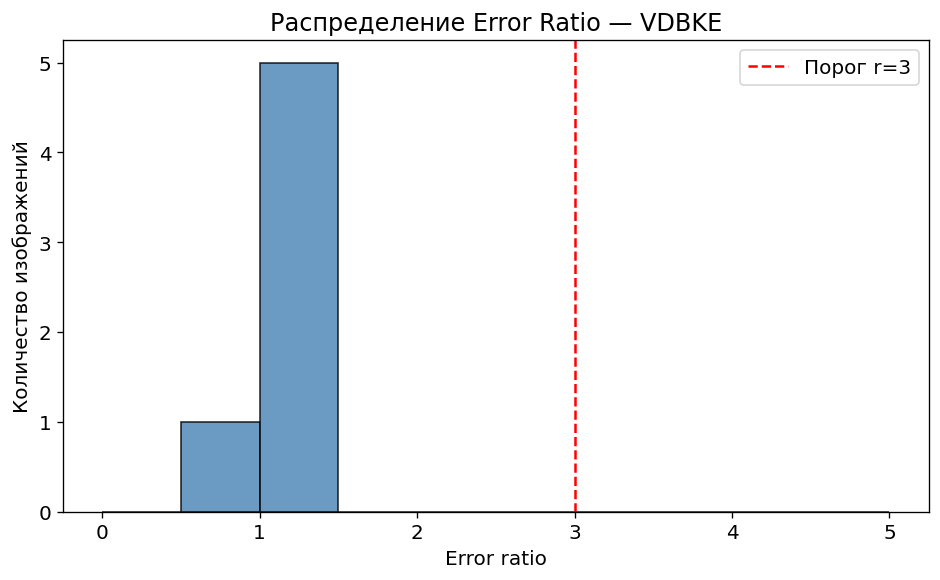

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\tex\error_ratio_histogram.tex


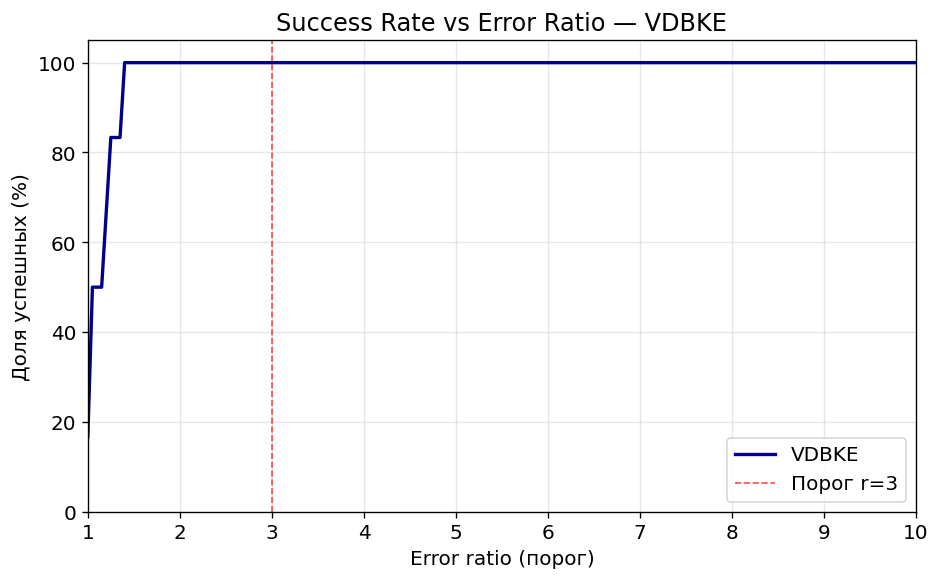

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\tex\success_rate.tex


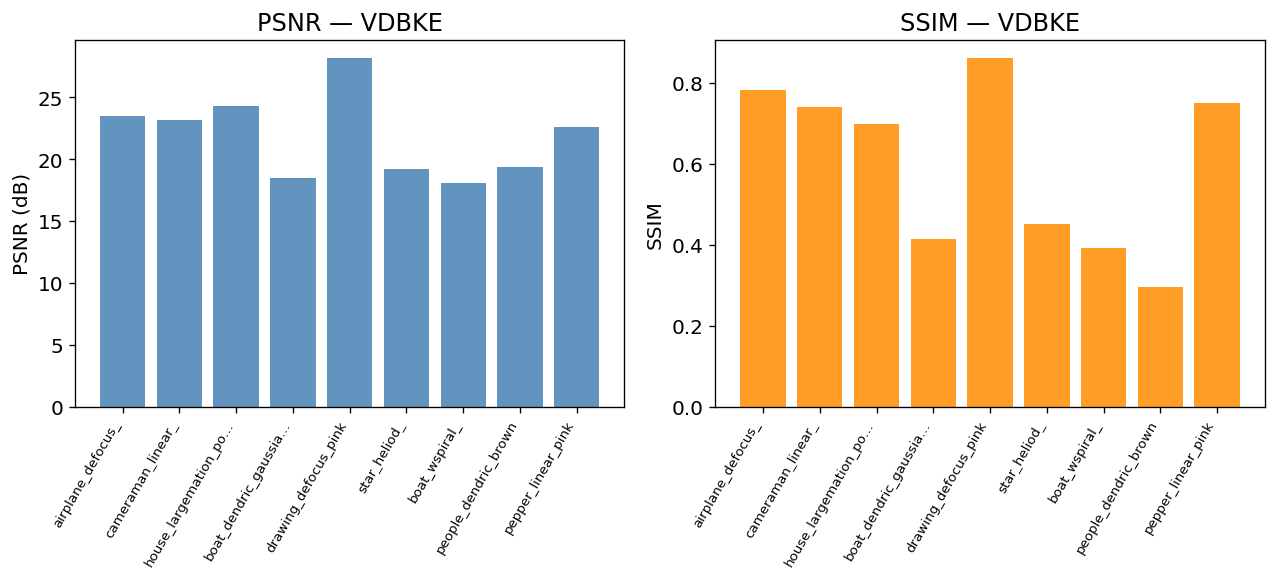

2026-04-13 18:08:35,092 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 18:08:35,099 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 18:08:35,103 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-13 18:08:35,103 - matplotlib.category - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\tex\psnr_ssim_bar.tex


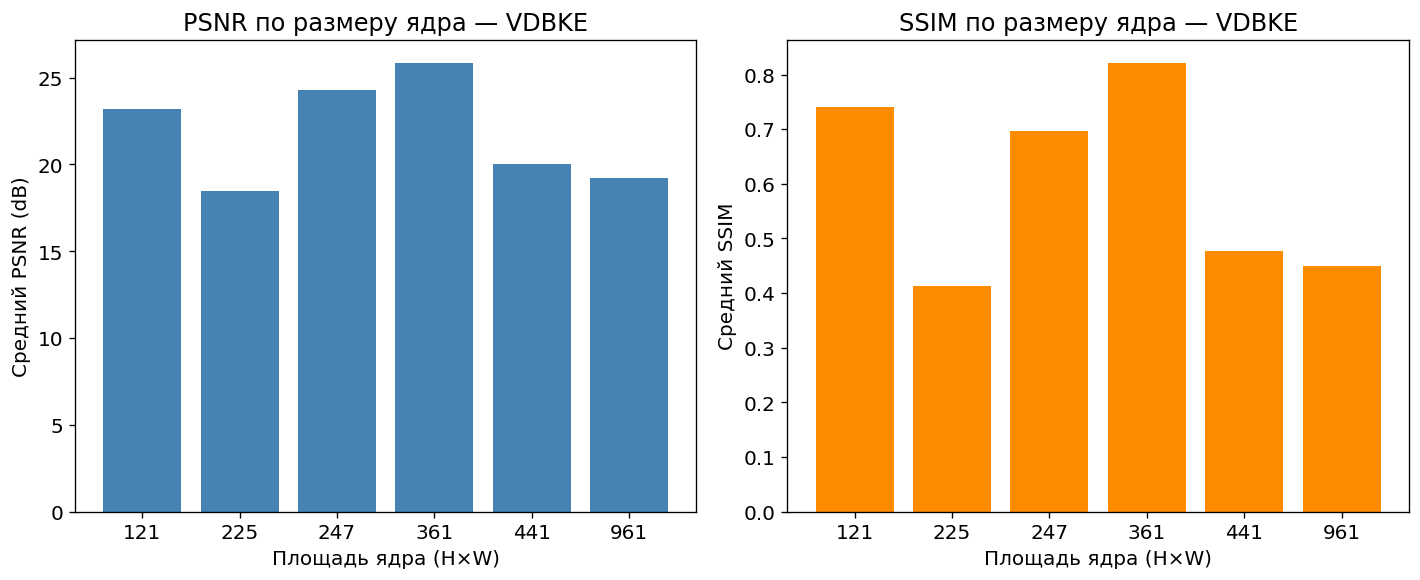

  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\tex\kernel_size_dependency.tex


,Датасет,Кол-во,PSNR (среднее),SSIM (среднее),Error Ratio (среднее),"Время (среднее, с)"
0,test1,3,23.67,0.7398,1.07,67.14
1,test2,3,21.96,0.5752,1.15,96.81
2,test3,3,20.04,0.4779,—,194.09


  TeX сохранён: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\tex\summary_table.tex

Общий CSV: D:\for_proga\franework_deconvolution\framework (9)\presentation_graphics\VDBKE\all_results_VDBKE.csv


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# ЯЧЕЙКА 3. Финальная сводка для одного алгоритма
# ══════════════════════════════════════════════════════════════════════════════

# Объединяем все результаты
df_all = pd.concat([r['df'] for r in ALL_DATASET_RESULTS], ignore_index=True)
print(f"Всего обработано изображений: {len(df_all)}\n")

TEX_DIR = ALG_RESULTS_DIR / "tex"
TEX_DIR.mkdir(exist_ok=True)
FIG_DIR = ALG_RESULTS_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)

# ─── 6. Гистограмма распределения отношения ошибки ───────────────────────────
vis.plot_error_ratio_histogram_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 2. Доля успешных / отношение ошибки ─────────────────────────────────────
vis.plot_success_rate_single(
    df_all['error_ratio'], ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 3. Столбчатая диаграмма PSNR / SSIM по изображениям ─────────────────────
vis.plot_psnr_ssim_bars_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 8. Зависимость от размера ядра ──────────────────────────────────────────
vis.plot_kernel_size_dependency_single(
    df_all, ALGORITHM_LABEL, fig_dir=FIG_DIR, tex_dir=TEX_DIR
)

# ─── 10. Таблица средних метрик по наборам данных ─────────────────────────────
df_summary = vis.build_summary_single(
    ALL_DATASET_RESULTS, ALGORITHM_LABEL, tex_dir=TEX_DIR
)
display(df_summary)

# Сохраняем объединённый CSV
df_all.to_csv(ALG_RESULTS_DIR / f"all_results_{ALGORITHM_LABEL}.csv", index=False)
print(f"\nОбщий CSV: {ALG_RESULTS_DIR / f'all_results_{ALGORITHM_LABEL}.csv'}")